## Data observation
**non-standard file format**

`*.ag` is not standard file format (like `*.csv`). However, the files contain tab-separated values

**Data fragmentation and invalid files**
Data is fragmented in multiple files in multiple directories. Each valid file contains Timestamp, measured value and instrument health data. alongside files with measurement data, there are also log files.

**Inconsistent files structure** 
File header is in some cases comma-separated and in other cases tab separated

```
Time	CO(ppm)	p_sample(in-hg-a)	f_sample(ccm)	co_meas(mV)	co_ref(mV)	mr_ratio	t_bench(C)	t_wheel(C)	t_oven(C)	t_box(C)
```
vs.
```
Time,CO(ppm),p_sample(in-hg-a),f_sample(ccm),co_meas(mV),co_ref(mV),mr_ratio,t_bench(C),t_wheel(C),t_oven(C),t_box(C)
```

**Invalid timestamps**

Example on the 2nd line (`1.179`)
Example:
```
231129165004	1.179	48.0	62.0	46.0	40.8	0.404	25.5	1515.0	3267.9	2759.3	
1.179	25.5	1512.0	3267.8	2758.3	1.179	48.0	62.7	46.0	
231129165024	40.8	0.405	25.5	1514.0	3271.1	2761.3	1.179	48.0	61.8	46.0
```

**Corrupted files**

invalid characters ath the end of some files - manually corrected

Example files with corrupted content:
- `/Tvarminne/Trace_gases/CO/2025/CO_tele_250507.ag`
- `/Tvarminne/Trace_gases/CO/2025/CO_tele_250721.ag`

**Invalid recods** 

In file `/Tvarminne/Trace_gases/CO/2025/CO_tele_251110.ag`

```
251110050800	0.059	29.0	1687.0	4225.5	3555.9	1.18	47.9	62.0	46.0	40.8	
251110050820	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110050911	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110051003	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110051054	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
251110051146	nan	nan	nan	nan	nan	nan	nan	nan	nan	nan	
```

Many files miss value in many records.

**Inconsistency in column order**

SO2 has values in third column insted of second

```
Time		flag		SO2		hiso2		intt		rctt		pgast		pres		smplfl		pmtv		lmpv		lmpi
221221000047	4C000000	0.20	0.00	28.0	44.8	0.00	723.6	0.476	-714.1	1015	90.00*	
221221000147	4C000000	0.20	0.00	28.0	44.8	0.00	723.6	0.476	-714.1	1015	90.00*	
221221000247	4C000000	0.20	0.00	28.0	44.8	0.00	723.6	0.476	-714.1	1015	90.00*	
```

# Loading data from files

Notebook-specific imports and constants

In [34]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from atmdp003.utils.config import TRACEGASES_RAW_DIR_PATH


tracegases_raw_dir_path = TRACEGASES_RAW_DIR_PATH()

DATA_MAP = {
    "CO": {
        "columns" : ["CO"],
        "n": [1],
        "units": ["ppb"],
    },
    "NO": {
        "columns" : ["NO", "NO2"],
        "n": [1, 2],
        "units": ["ppb", "ppb"]
    },
    "O3": {
        "columns" : ["O3"],
        "n": [1],
        "units": ["ppb"]
    },
    "SO2": {
        "columns" : ["SO2"],
        "n": [2],
        "units": ["ppb"]
    }
}

Load all data and combine it into single DataFrame `df`,
 negative values replaced with `NaN`

In [ ]:
print(f"Raw data directory: {tracegases_raw_dir_path}")

dfs_gas = []

for gas, details in DATA_MAP.items():
    print(f"Processing {gas:<4}: {details}")
    path = Path(f"{tracegases_raw_dir_path}/{gas}")
    files_to_process = path.glob("*/*.ag")

    dfs = []
    for file in files_to_process:
        df = pd.read_csv(file, skiprows=1, header=None, sep=r'\s+', engine='python')
        keep_cols = [0] + details["n"]  # always keep the first column (timestamp) and the columns specified in details
        df = df.iloc[:, keep_cols]
        # setting column names
        df.columns = ["Time"] + details["columns"]
        # Converting first column (timestamps) to numeric, coercing errors to NaN
        df["Time"] = pd.to_numeric(df["Time"], errors='coerce')
        df["Time"] = pd.to_datetime(df["Time"], format='%y%m%d%H%M%S', errors='coerce')
        df.dropna(subset=["Time"], inplace=True)  # Drop rows where Time conversion failed
        for col in details["columns"]:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[col] = df[col].mask(df[col] < 0, np.nan) 
        df = df.dropna(subset=details["columns"], how="all")
        # setting Time as index
        df.set_index("Time", inplace=True)
        df.columns = [f"{col}_{unit}" for col, unit in zip(details["columns"], details["units"])]
        # appending to list of dataframes for this gas
        dfs.append(df)
        
    df = pd.concat(dfs, ignore_index=False)
    duplicate_mask = df.index.duplicated(keep='first')
    print(f" - removing {duplicate_mask.sum()} rows - duplicate index")
    df = df[~duplicate_mask]
    # df = df.sort_index()
    dfs_gas.append(df)
    print(f" - df of {gas} has shape {df.shape}")
    print(f"  \\- index name: {df.index.name}, type: {df.index.dtype}")
    
df = pd.concat(dfs_gas, axis=1, sort=True)
print(f"combined df has shape {df.shape}")
print(df)

Raw data directory: /Users/rohal/projects/winterschool2026/ATMDP-003/local/trace_gases
Processing CO  : {'columns': ['CO'], 'n': [1], 'units': ['ppb']}
 - removing 3429 rows - duplicate index
 - df of CO has shape (7182693, 1)
  \- index name: Time, type: datetime64[us]
Processing NO  : {'columns': ['NO', 'NO2'], 'n': [1, 2], 'units': ['ppb', 'ppb']}
 - removing 0 rows - duplicate index
 - df of NO has shape (7411903, 2)
  \- index name: Time, type: datetime64[us]
Processing O3  : {'columns': ['O3'], 'n': [1], 'units': ['ppb']}
 - removing 491 rows - duplicate index
 - df of O3 has shape (8260087, 1)
  \- index name: Time, type: datetime64[us]
Processing SO2 : {'columns': ['SO2'], 'n': [2], 'units': ['ppb']}
 - removing 0 rows - duplicate index
 - df of SO2 has shape (842996, 1)
  \- index name: Time, type: datetime64[us]
combined df has shape (16445440, 5)
                     CO_ppb  NO_ppb  NO2_ppb  O3_ppb  SO2_ppb
Time                                                         
2022-1

Plot raw data

___________

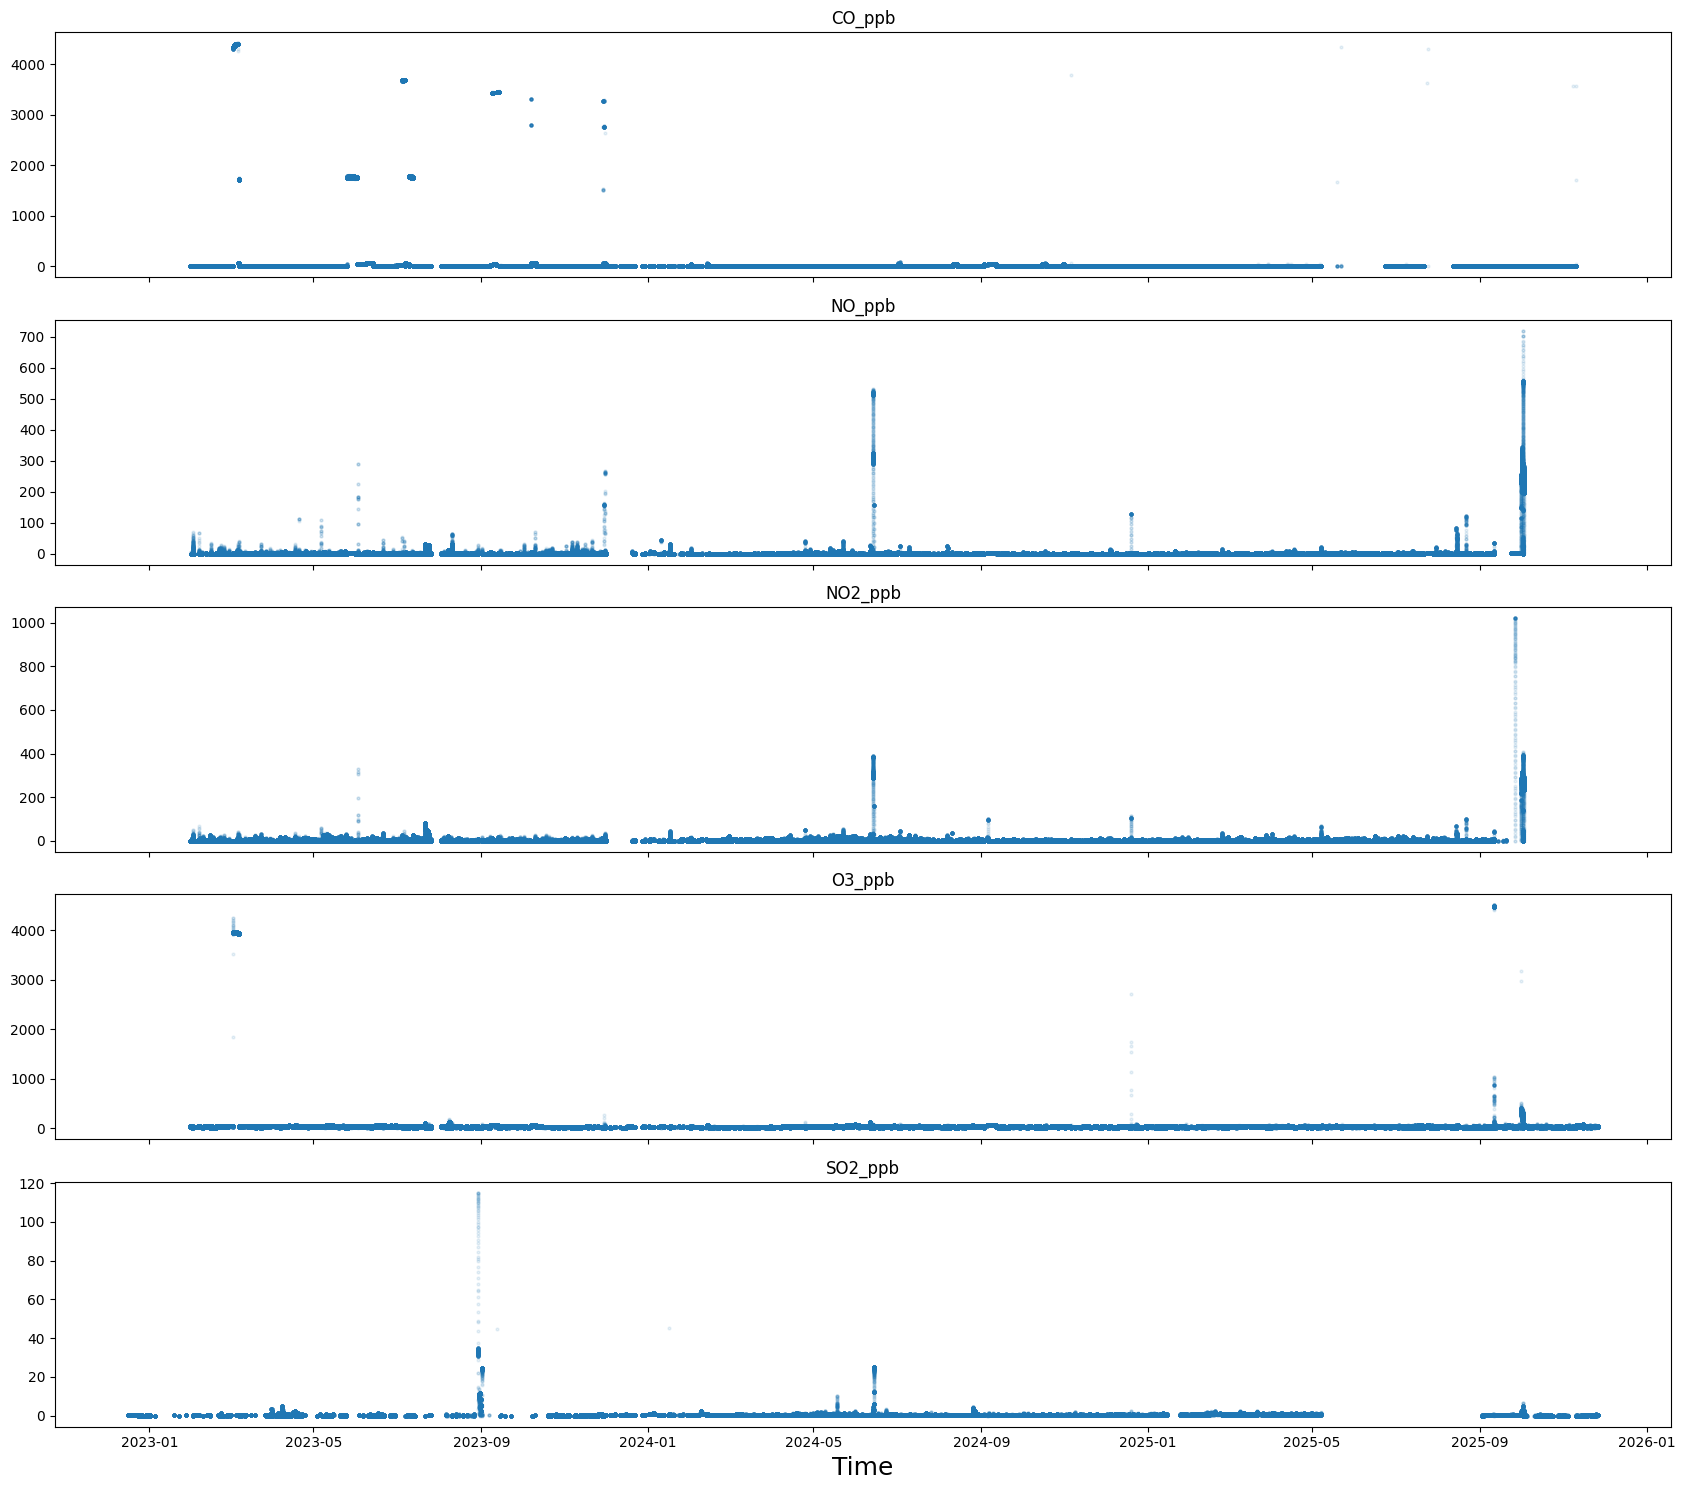

In [36]:
fig, axes = plt.subplots(
    df.shape[1],
    1,
    figsize=(17, 15),
    sharex=True,
)

for i, col in enumerate(df.columns):
    ax = axes[i]
    ax.plot(df.index, df[col], label=f"{col}", marker='o', markersize=2, linestyle='None', alpha=0.1)
    ax.set_title(col)
    
plt.xlabel("Time", fontsize=18)
plt.tight_layout()
plt.show()

Outliers, clear instrument malfunction


Hourly median

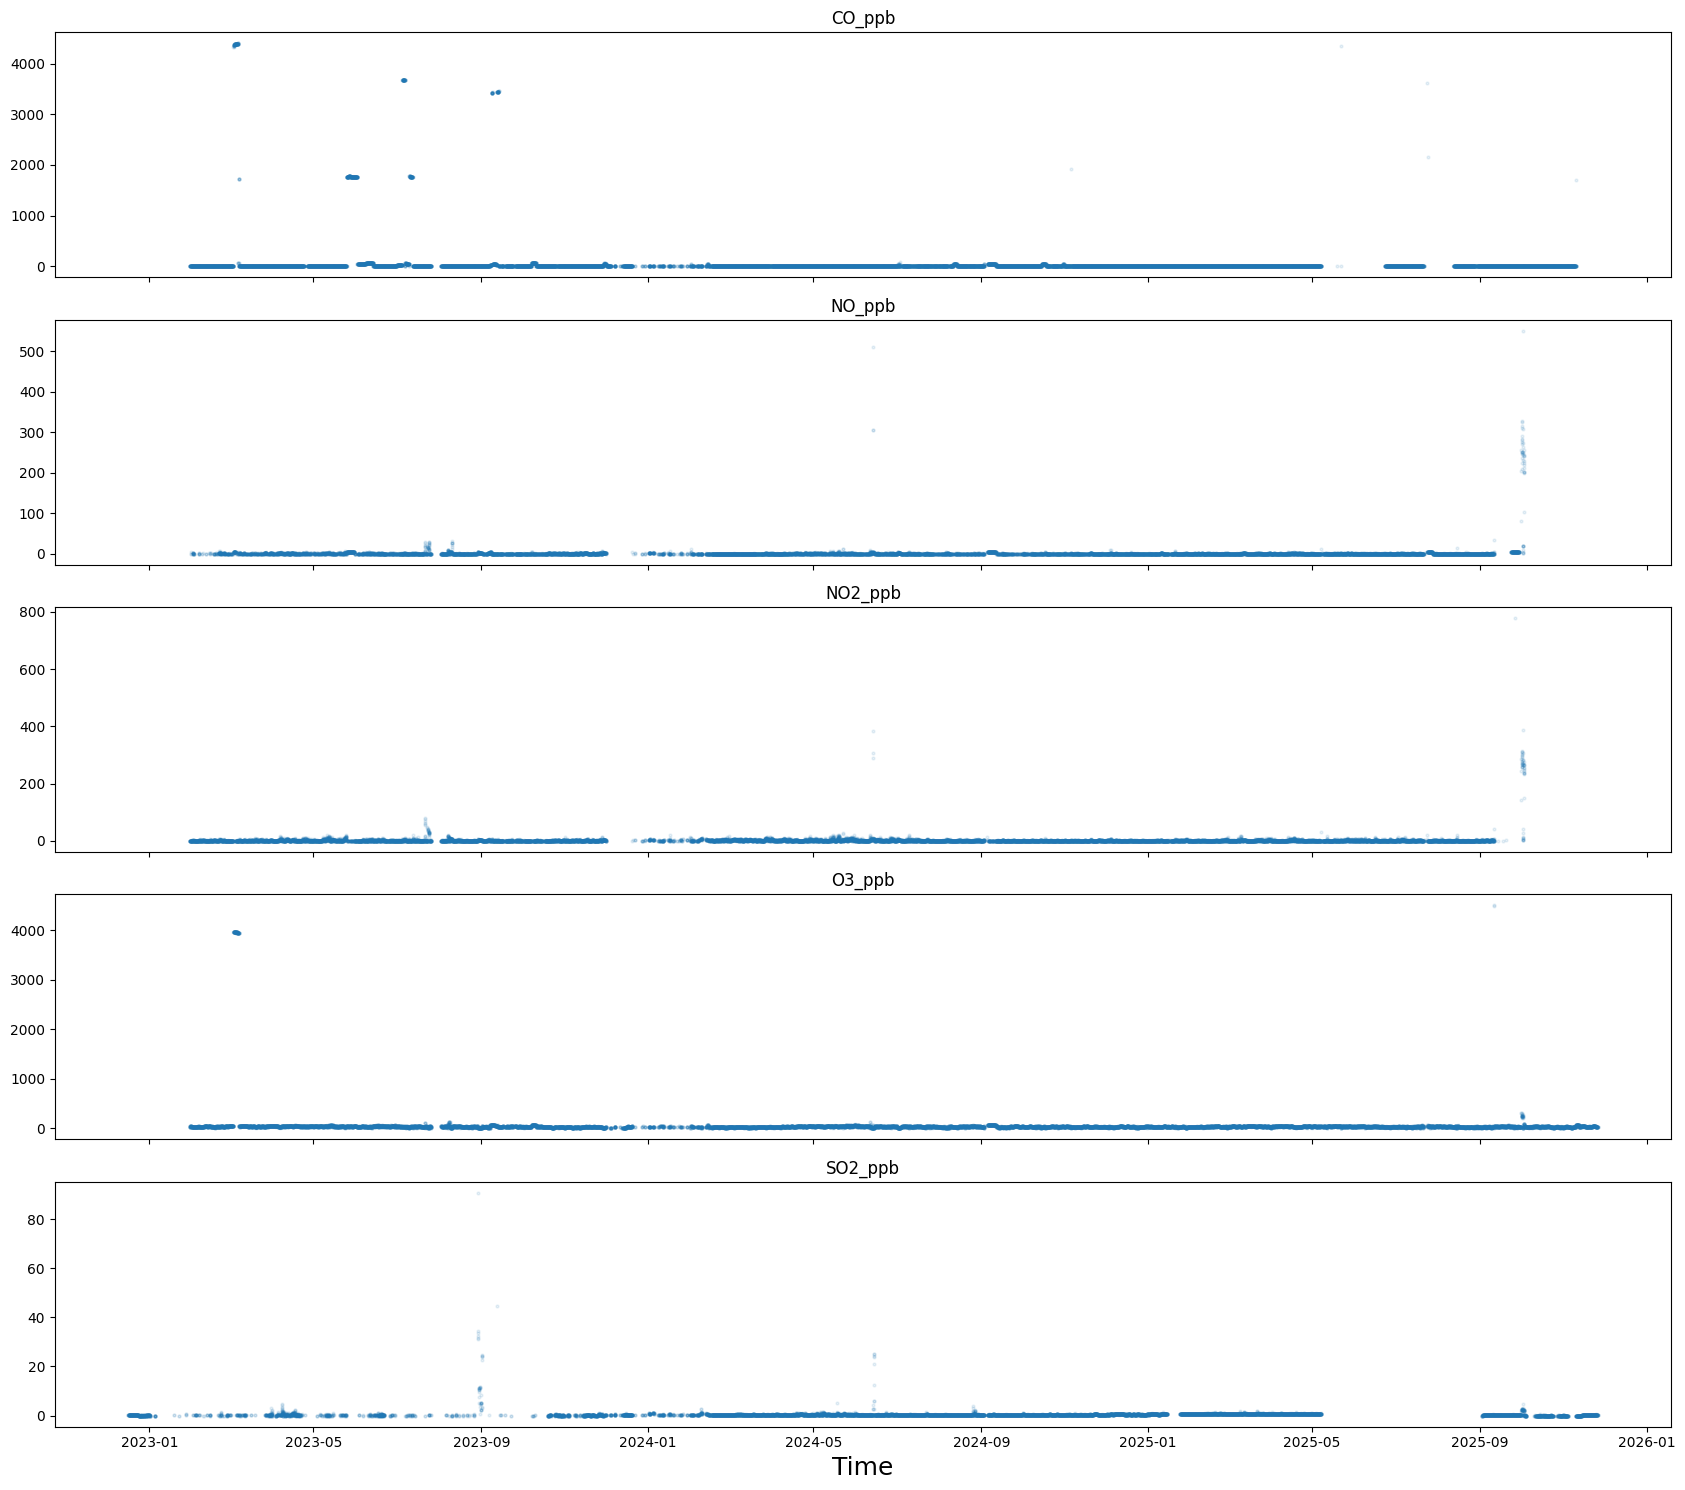

In [37]:
df_h = df.resample("h").median()

fig, axes = plt.subplots(
    df_h.shape[1],
    1,
    figsize=(17, 15),
    sharex=True,
)

for i, col in enumerate(df_h.columns):
    ax = axes[i]
    ax.plot(df_h.index, df_h[col], label=f"{col}", marker='o', markersize=2, linestyle='None', alpha=0.1)
    ax.set_title(col)
    
plt.xlabel("Time", fontsize=18)
plt.tight_layout()
plt.show()